In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score,auc,accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


<h2>Special Features Classification Analysis</h2>

In [3]:
df=pd.read_csv("./Data/train_data.csv")
test=pd.read_csv("./Data/test_data.csv")
test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


<h2>Preprocessing</h2>

In [4]:
y_train=df['class']
y_test=test['class']
X_train=df.drop(labels="class",axis=1)
X_test=test.drop(labels="class",axis=1)

#standard scaling
scaler=StandardScaler()
columns=X_train.columns
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=columns)
X_test=pd.DataFrame(scaler.transform(X_test),columns=columns)

#features found out by research
features=['Autocorrelation','Contrast','Correlation','Dissimilarity','Entropy',' Homogeneity','Homogeneity: [2]']
X_sub_train=X_train[features]
X_sub_test=X_test[features]


In [5]:
X_sub_test.head()


,Autocorrelation,Contrast,Correlation,Dissimilarity,Entropy,Homogeneity,Homogeneity: [2]
0,0.103789,1.135458,-0.068860,0.744575,0.552925,-0.584817,-0.618128
1,-0.680372,-0.096930,-0.590980,-0.536722,-0.678133,0.647681,0.629611
2,0.520681,2.596747,-0.363470,1.322993,0.800081,-0.909542,-0.969915
3,-0.899305,-0.586223,-1.603131,-0.746084,-0.859438,0.786830,0.772513
4,0.055406,1.564583,-0.151808,0.515526,0.099613,-0.181000,-0.233644


In [6]:
#helpful functions
#helper functions
def score(y_test,predictions):
    print(classification_report(y_test,predictions))
    print(pd.DataFrame(predictions).value_counts())
    print("Accuracy score ={score}".format(score=accuracy_score(y_test,predictions)))

def plot_matrix(y_test,predictions,filepath):
    matrix=confusion_matrix(y_test,predictions)
    matrix=matrix.transpose()
    cm_df=pd.DataFrame(matrix,index=["Early Blight","Late Blight","Healthy"],columns=["Early Blight","Late Blight","Healthy"])
    sns.heatmap(cm_df,annot_kws={"size":16},annot=True,fmt="d")
    plt.title("Confusion Matrix for Random Forest")
    plt.savefig(filepath,dpi=1200)
    
def plot_roc(y_test,predictions,save_path):
    actual_vals=pd.DataFrame(pd.get_dummies(y_test))
    predictions=pd.DataFrame(pd.get_dummies(predictions))
    print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
    print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
    print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
    predictions.head()
    #compute roc curve and roc area for each curve
    fpr=dict()
    tpr=dict()
    roc_auc=dict()
    n_classes=3

    #loop for each class
    for i in range(n_classes):
        fpr[i],tpr[i],_=roc_curve(actual_vals.iloc[:,i],predictions.iloc[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])
    #micro-average roc curve
    fpr["micro"],tpr["micro"],_=roc_curve(actual_vals.to_numpy().ravel(),predictions.to_numpy().ravel())
    roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])
    
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    #main plotter
    lw=2
    plt.figure(figsize=(10,8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    labels=['EB','LB','H']
    for i,color in zip(range(n_classes),colors):
         plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
                 ''.format(i, name=labels[i],area=roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Random Forest')
    plt.legend(loc="lower right")
    # plt.show()
    plt.savefig(save_path,dpi=1200)

<h2>Support Vector Machine RBF Kernel</h2>

<h2>Performing Hyperparameter tuning</h2>

In [7]:
C=[0.01,0.03,0.1,0.3,1,3,10,30,100]
sigma=[0.01,0.03,0.1,0.3,1,3,10,30,100]

params={'C':C,'gamma':sigma,'kernel':['rbf']}

grid_s=GridSearchCV(SVC(random_state=42),param_grid=params,verbose=0)
grid_s.fit(X_sub_train,y_train)

GridSearchCV(estimator=SVC(random_state=42),
             param_grid={'C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'gamma': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                         'kernel': ['rbf']})

In [8]:
print(grid_s.best_estimator_)
print(grid_s.best_params_)

SVC(C=10, gamma=0.1, random_state=42)
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [9]:
model=SVC(C=10, gamma=0.1, random_state=42)
model.fit(X_sub_train,y_train)
predictions=model.predict(X_sub_test)

In [10]:
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.82      0.96      0.89        57
           1       0.97      0.84      0.90        74
           2       1.00      1.00      1.00        61

    accuracy                           0.93       192
   macro avg       0.93      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192

0    67
1    64
2    61
dtype: int64
Accuracy score =0.9270833333333334


<h2>Confusion Matrix</h2>

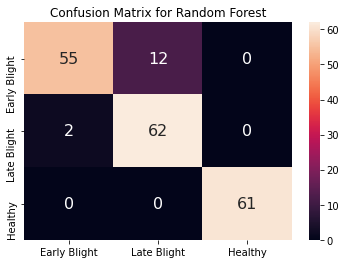

In [11]:
plot_matrix(y_test,predictions,'./images/Research Features/SVM/SVMConfMatrix.png')

<h2>ROC Curve</h2>

0: 67
1 :64
2 :61


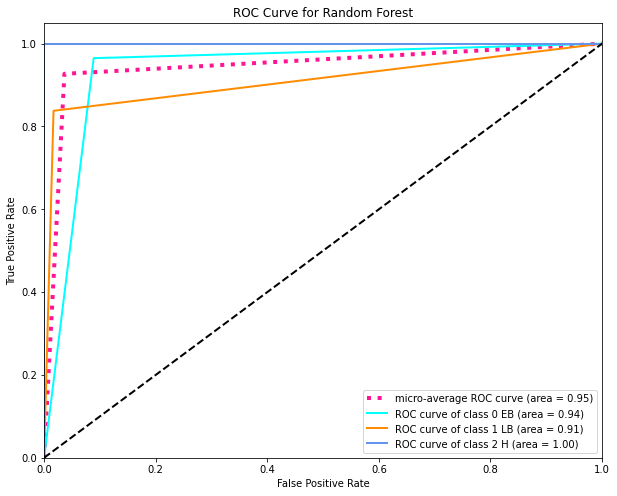

In [12]:
plot_roc(y_test,predictions,'./images/Research Features/SVM/SVMROC.png')

<h2>K-means Clustering</h2>

In [13]:
model=KMeans(n_clusters=3,init='k-means++',n_init=10,max_iter=1000,random_state=42,algorithm="full")
model.fit(X_sub_train,y_train)
predictions=model.predict(X_sub_test)

In [14]:
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.05      0.05      0.05        57
           1       0.64      0.78      0.70        74
           2       0.03      0.02      0.02        61

    accuracy                           0.32       192
   macro avg       0.24      0.28      0.26       192
weighted avg       0.27      0.32      0.29       192

1    91
0    63
2    38
dtype: int64
Accuracy score =0.3229166666666667


<h2>Confusion Matrix</h2>

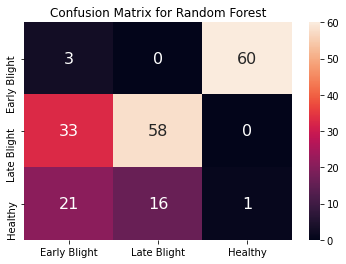

In [15]:
plot_matrix(y_test,predictions,'./images/Research Features/KMeans/KmeansConfMatrix.png')

<h2>ROC Curve</h2>

0: 63
1 :91
2 :38


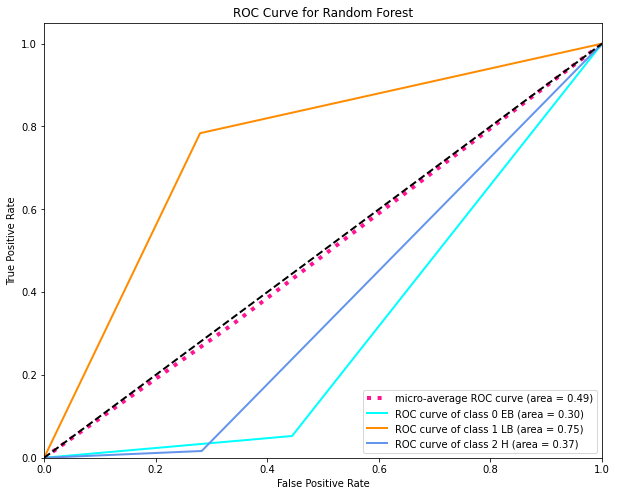

In [16]:
plot_roc(y_test,predictions,'./images/Research Features/KMeans/KmeansROC.png')

 <h2>KMeans with PCA</h2>

In [35]:
pca = PCA(n_components=3,copy=True)
transformed_train=pca.fit_transform(X_sub_train)
transformed_train.shape

(120, 3)

In [36]:
columns=['feature 1','feature 2','feature 3']
transformed_train=pd.DataFrame(transformed_train,columns=columns)
print(transformed_train.shape)
transformed_train.head()

(120, 3)


,feature 1,feature 2,feature 3
0,1.457814,0.704357,-0.494618
1,-1.449164,0.465933,-0.238128
2,2.695944,1.629051,-1.127273
3,-2.188689,1.121866,0.428275
4,0.966017,0.901678,-0.988280


In [37]:
model=KMeans(n_clusters=3,init='k-means++',n_init=10,max_iter=1000,random_state=42,algorithm="full")
model.fit(transformed_train)
prediction=model.predict(transformed_train)

In [38]:
score(prediction,y_train)

              precision    recall  f1-score   support

           0       0.10      0.09      0.10        43
           1       0.80      0.59      0.68        54
           2       0.03      0.04      0.03        23

    accuracy                           0.31       120
   macro avg       0.31      0.24      0.27       120
weighted avg       0.40      0.31      0.35       120

class
0        40
1        40
2        40
dtype: int64
Accuracy score =0.30833333333333335


In [41]:
pca = PCA(n_components=3,copy=True)
transformed_test=pca.fit_transform(X_sub_test)
transformed_test.shape

(192, 3)

In [42]:
columns=['feature 1','feature 2','feature 3']
transformed_test=pd.DataFrame(transformed_test,columns=columns)

In [44]:
predictions=model.predict(transformed_test)
score(predictions,y_test)

              precision    recall  f1-score   support

           0       0.07      0.06      0.07        64
           1       0.78      0.64      0.71        90
           2       0.02      0.03      0.02        38

    accuracy                           0.33       192
   macro avg       0.29      0.24      0.26       192
weighted avg       0.39      0.33      0.36       192

class
1        74
2        61
0        57
dtype: int64
Accuracy score =0.328125


<h2>Confusion Matrix</h2>

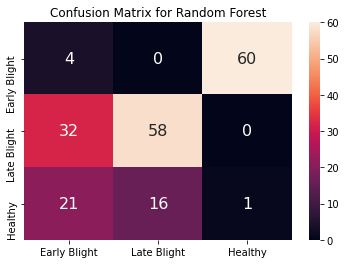

In [45]:
plot_matrix(y_test,predictions,'./images/Research Features/KMeans/KmeansPCAConfMatrix.png')

<h2>ROC Curve</h2>

0: 64
1 :90
2 :38


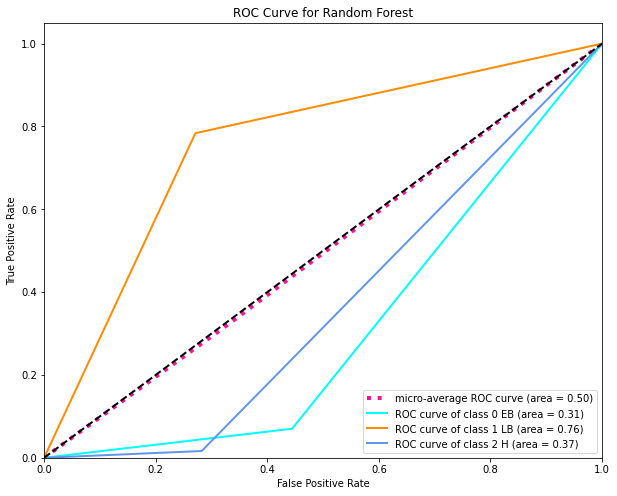

In [46]:
plot_roc(y_test,predictions,'./images/Research Features/KMeans/KmeansPCA_ROC.png')

<h2>Now adding artificial neural network</h2>

In [47]:
import tensorflow as tf

In [53]:
model=tf.keras.Sequential()
#28 neurons output 7 input feature vector size
model.add(tf.keras.layers.Dense(units=28,activation='relu',input_shape=(7,)))

In [54]:
#adding dropout for regularization
model.add(tf.keras.layers.Dropout(0.2))

In [55]:
#adding output layer
model.add(tf.keras.layers.Dense(units=3,activation='softmax'))

In [56]:
#compile model
model.compile(optimizer="adam",loss = 'sparse_categorical_crossentropy',metrics = ['sparse_categorical_accuracy'])

In [57]:
#fitting the model
model.fit(X_sub_train,y_train,epochs=100)

Epoch 1/100
4/4 [==============================] - 1s 2ms/step - loss: 1.0829 - sparse_categorical_accuracy: 0.4667
Epoch 2/100
4/4 [==============================] - 0s 2ms/step - loss: 1.0182 - sparse_categorical_accuracy: 0.5667
Epoch 3/100
4/4 [==============================] - 0s 2ms/step - loss: 0.9674 - sparse_categorical_accuracy: 0.6250
Epoch 4/100
4/4 [==============================] - 0s 2ms/step - loss: 0.8955 - sparse_categorical_accuracy: 0.7000
Epoch 5/100
4/4 [==============================] - 0s 2ms/step - loss: 0.8932 - sparse_categorical_accuracy: 0.7083
Epoch 6/100
4/4 [==============================] - 0s 2ms/step - loss: 0.8500 - sparse_categorical_accuracy: 0.7500
Epoch 7/100
4/4 [==============================] - 0s 1ms/step - loss: 0.8038 - sparse_categorical_accuracy: 0.7583
Epoch 8/100
4/4 [==============================] - 0s 2ms/step - loss: 0.7565 - sparse_categorical_accuracy: 0.8500
Epoch 9/100
4/4 [==============================] - 0s 1ms/step - loss: 0

4/4 [==============================] - 0s 834us/step - loss: 0.3519 - sparse_categorical_accuracy: 0.9083
Epoch 71/100
4/4 [==============================] - 0s 845us/step - loss: 0.3184 - sparse_categorical_accuracy: 0.9000
Epoch 72/100
4/4 [==============================] - 0s 892us/step - loss: 0.3277 - sparse_categorical_accuracy: 0.9000
Epoch 73/100
4/4 [==============================] - 0s 743us/step - loss: 0.3207 - sparse_categorical_accuracy: 0.9000
Epoch 74/100
4/4 [==============================] - 0s 794us/step - loss: 0.3115 - sparse_categorical_accuracy: 0.8750
Epoch 75/100
4/4 [==============================] - 0s 782us/step - loss: 0.3120 - sparse_categorical_accuracy: 0.8917
Epoch 76/100
4/4 [==============================] - 0s 782us/step - loss: 0.3023 - sparse_categorical_accuracy: 0.9083
Epoch 77/100
4/4 [==============================] - 0s 832us/step - loss: 0.3149 - sparse_categorical_accuracy: 0.8917
Epoch 78/100
4/4 [==============================] - 0s 868us/

In [58]:
test_loss,test_accuracy=model.evaluate(X_sub_test,y_test)

6/6 [==============================] - 0s 800us/step - loss: 0.2825 - sparse_categorical_accuracy: 0.9167


In [59]:
predictions=model.predict(X_sub_test)
predictions=tf.argmax(predictions,axis=1)
predictions

<tf.Tensor: shape=(192,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])>

In [60]:
predictions=np.array(predictions)
# predictions=pd.DataFrame(predictions,columns=["output"])
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [61]:
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.81      0.95      0.87        57
           1       0.95      0.82      0.88        74
           2       1.00      1.00      1.00        61

    accuracy                           0.92       192
   macro avg       0.92      0.92      0.92       192
weighted avg       0.92      0.92      0.92       192

0    67
1    64
2    61
dtype: int64
Accuracy score =0.9166666666666666


<h2>ROC Curve</h2>

0: 67
1 :64
2 :61


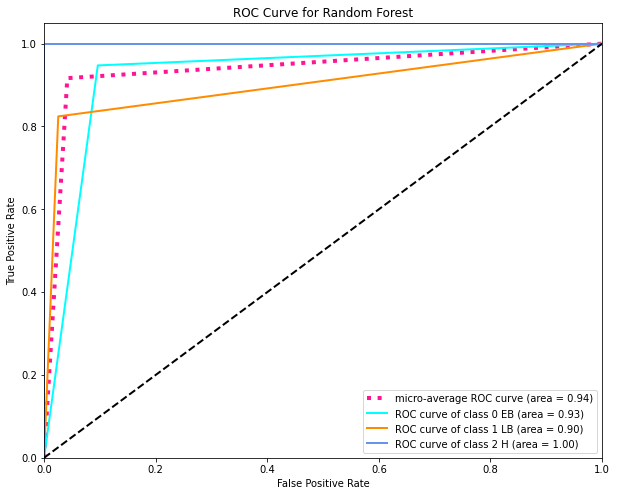

In [62]:
plot_roc(y_test,predictions,'./images/Research Features/Ann/AnnROC.png')

<h2>Confusion Matrix</h2>

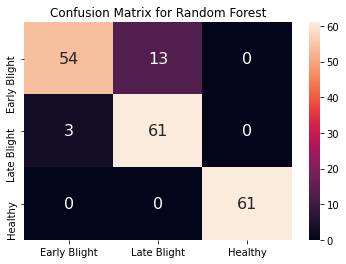

In [63]:
plot_matrix(y_test,predictions,'./images/Research Features/Ann/AnnConfusionMatrix.png')